# Visualisation

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import os

### LaTeX formatting setup

In [2]:
plt.rcParams.update({
    'text.usetex': False, 
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize': (8, 6),
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

STRATEGY_COLORS = {
    'random': '#1f77b4',      # blue
    'degree': '#ff7f0e',      # orange
    'betweenness': '#2ca02c'  # green
}

STRATEGY_NAMES = {
    'random': 'Random',
    'degree': 'Degree',
    'betweenness': 'Betweenness'
}

### Load data

In [3]:
data_files = {
    'per_run'        : 'ass2_per_run_all.csv',
    'aggregate'      : 'ass2_aggregate_all.csv', 
    'time_series'    : 'ass2_ts_all.csv',
    'mean_curves'    : 'ass2_mean_curves_all.csv',
    'adoption_times' : 'ass2_adoption_times_representative.csv'
}

data = {}
for name, file in data_files.items():
    if os.path.exists(file):
        data[name] = pd.read_csv(file)
        print(f"Loaded {file}: {len(data[name])} rows")
    else:
        print(f"Warning: {file} not found")
    

Loaded ass2_per_run_all.csv: 900 rows
Loaded ass2_aggregate_all.csv: 90 rows
Loaded ass2_ts_all.csv: 17110 rows
Loaded ass2_mean_curves_all.csv: 1971 rows
Loaded ass2_adoption_times_representative.csv: 401859 rows


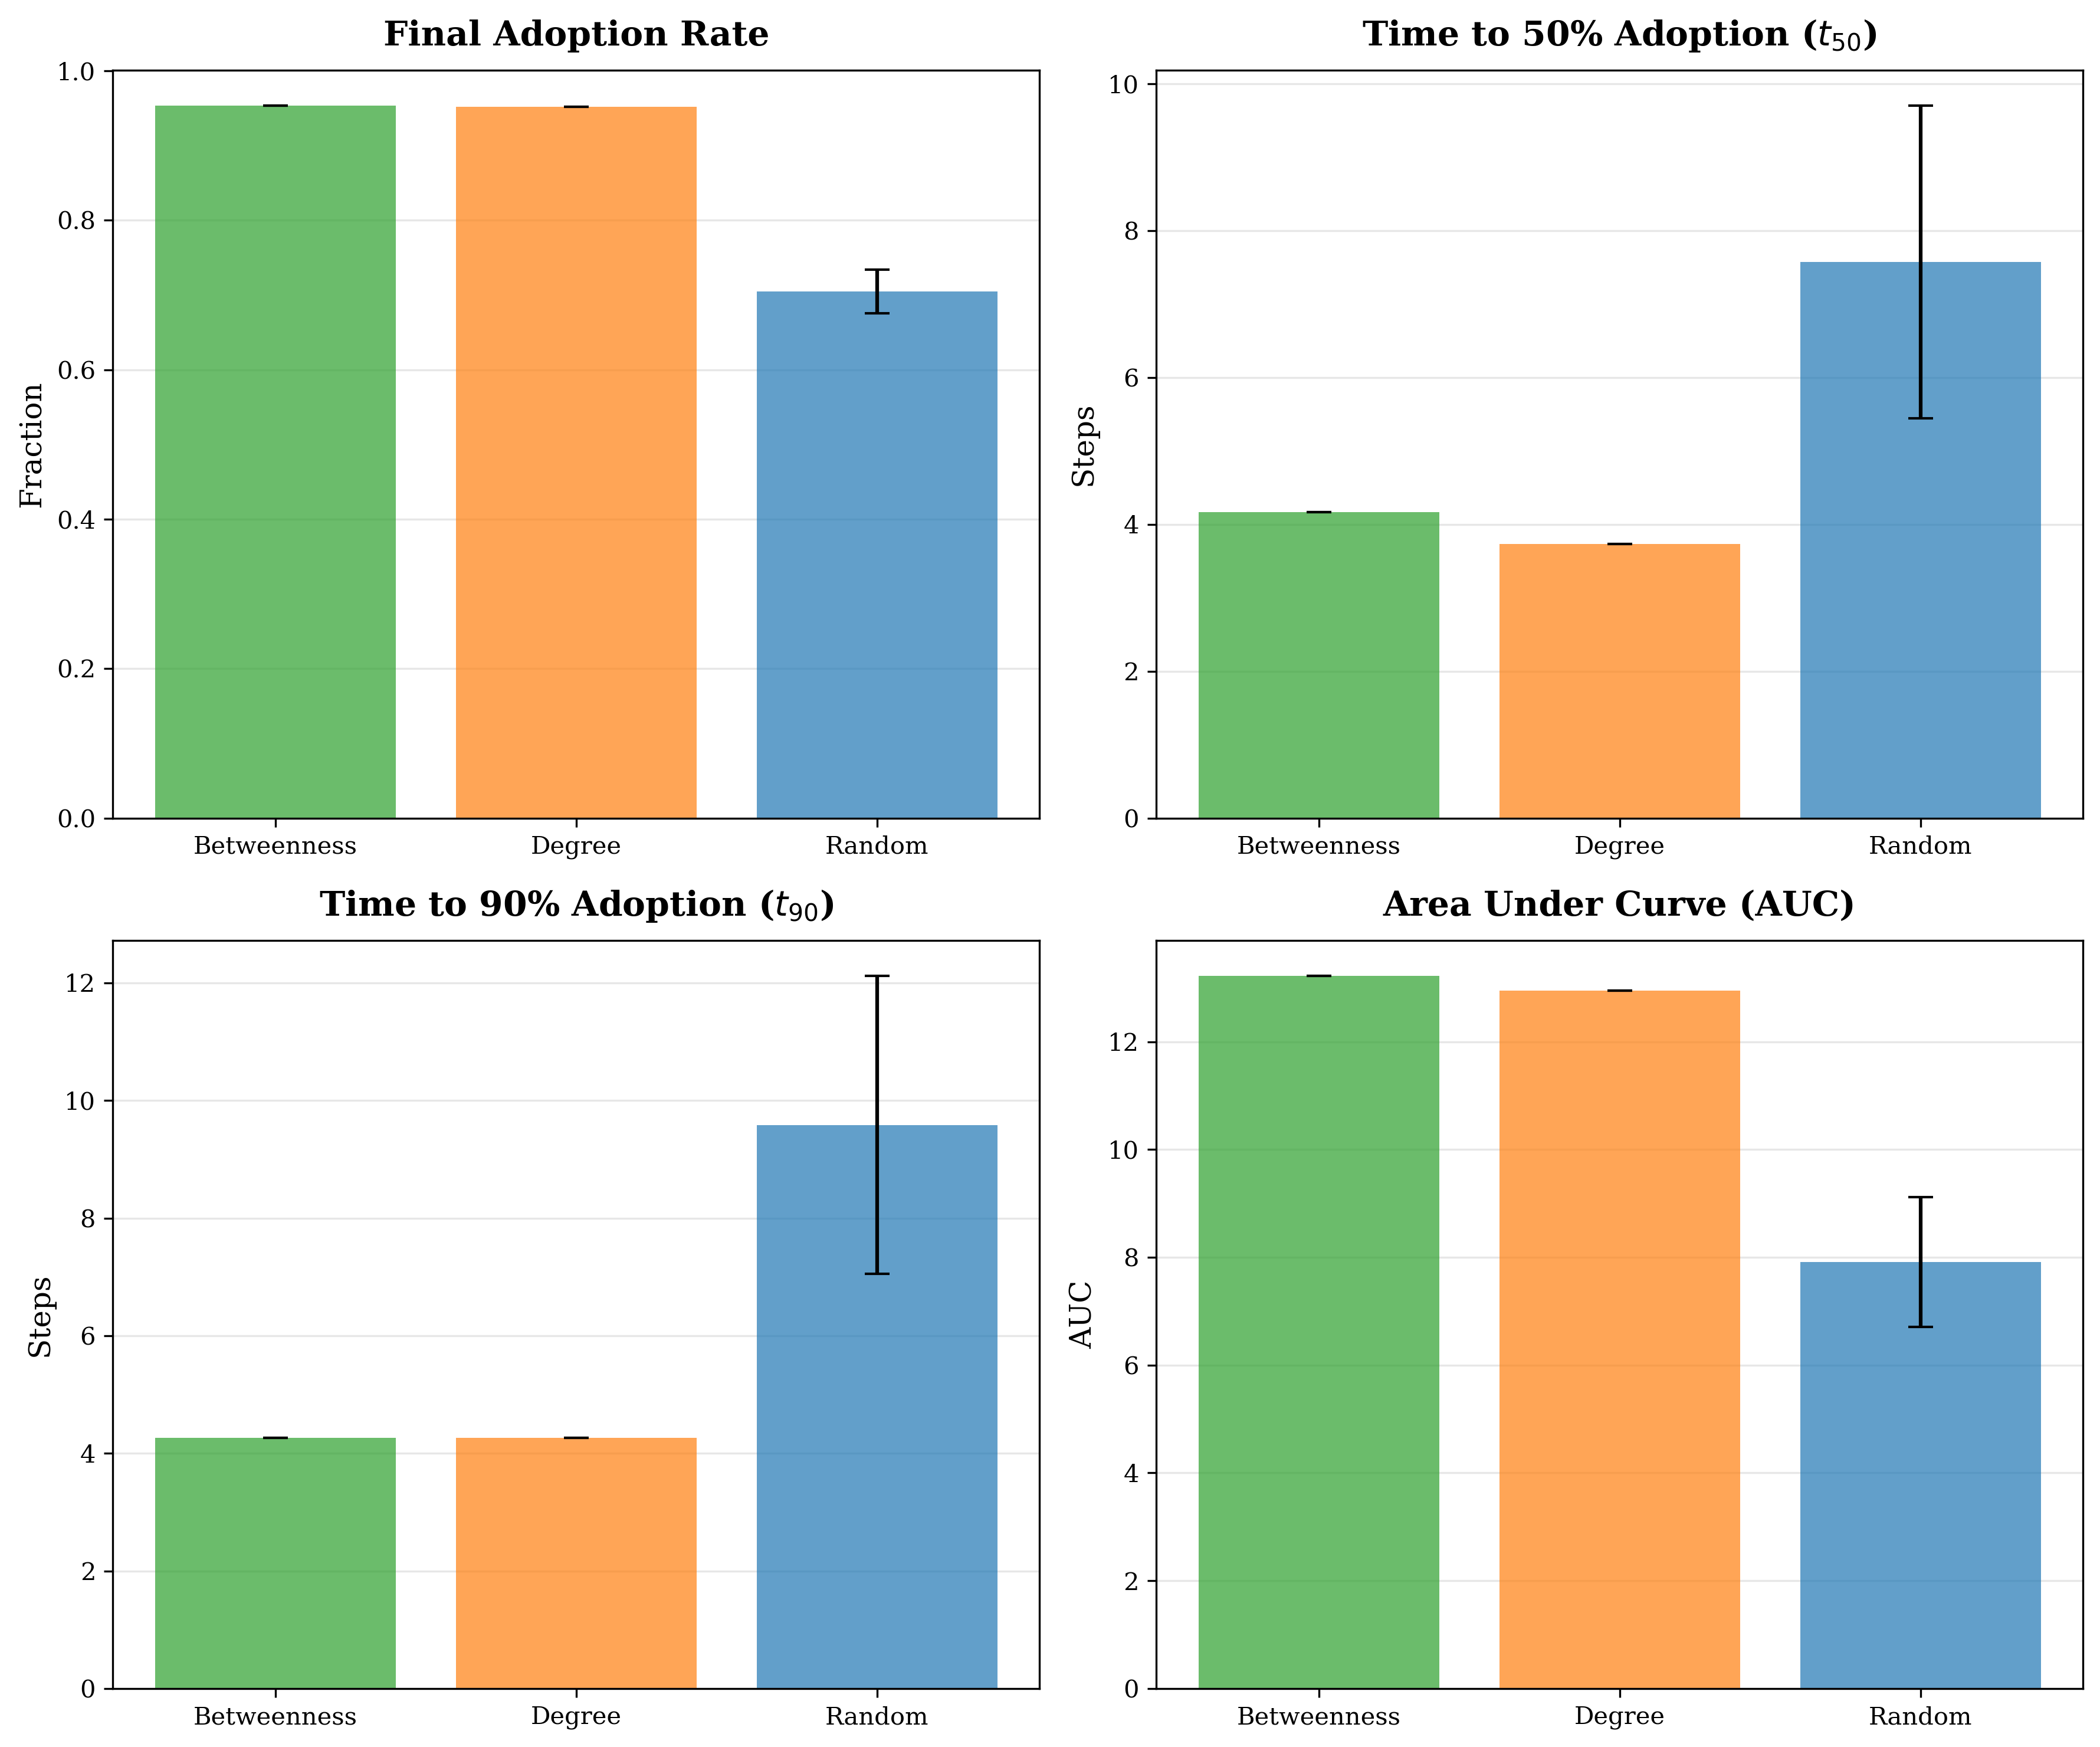

In [5]:
agg_df = data['aggregate']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

metrics = [
    ('mean_final_fraction', 'Final Adoption Rate', 'Fraction'),
    ('mean_t_50', 'Time to 50% Adoption ($t_{50}$)', 'Steps'),
    ('mean_t_90', 'Time to 90% Adoption ($t_{90}$)', 'Steps'), 
    ('mean_auc', 'Area Under Curve (AUC)', 'AUC')
]

for idx, (metric, title, ylabel) in enumerate(metrics):
    ax = axes[idx]
    
    strategies = agg_df['strategy'].unique()
    x_pos = np.arange(len(strategies))
    
    bars = []
    for i, strategy in enumerate(strategies):
        strategy_data = agg_df[agg_df['strategy'] == strategy]
        color = STRATEGY_COLORS.get(strategy, 'gray')
        
        bar = ax.bar(x_pos[i], strategy_data[metric].mean(), 
                    color=color, alpha=0.7, label=STRATEGY_NAMES.get(strategy, strategy))
        bars.append(bar)
        
        std_col = metric.replace('mean_', 'std_')
        if std_col in strategy_data.columns:
            ax.errorbar(x_pos[i], strategy_data[metric].mean(),
                        yerr=strategy_data[std_col].mean(), 
                        fmt='none', color='black', capsize=5, capthick=1)
    
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([STRATEGY_NAMES.get(s, s) for s in strategies])
    
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('plots\strategy_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


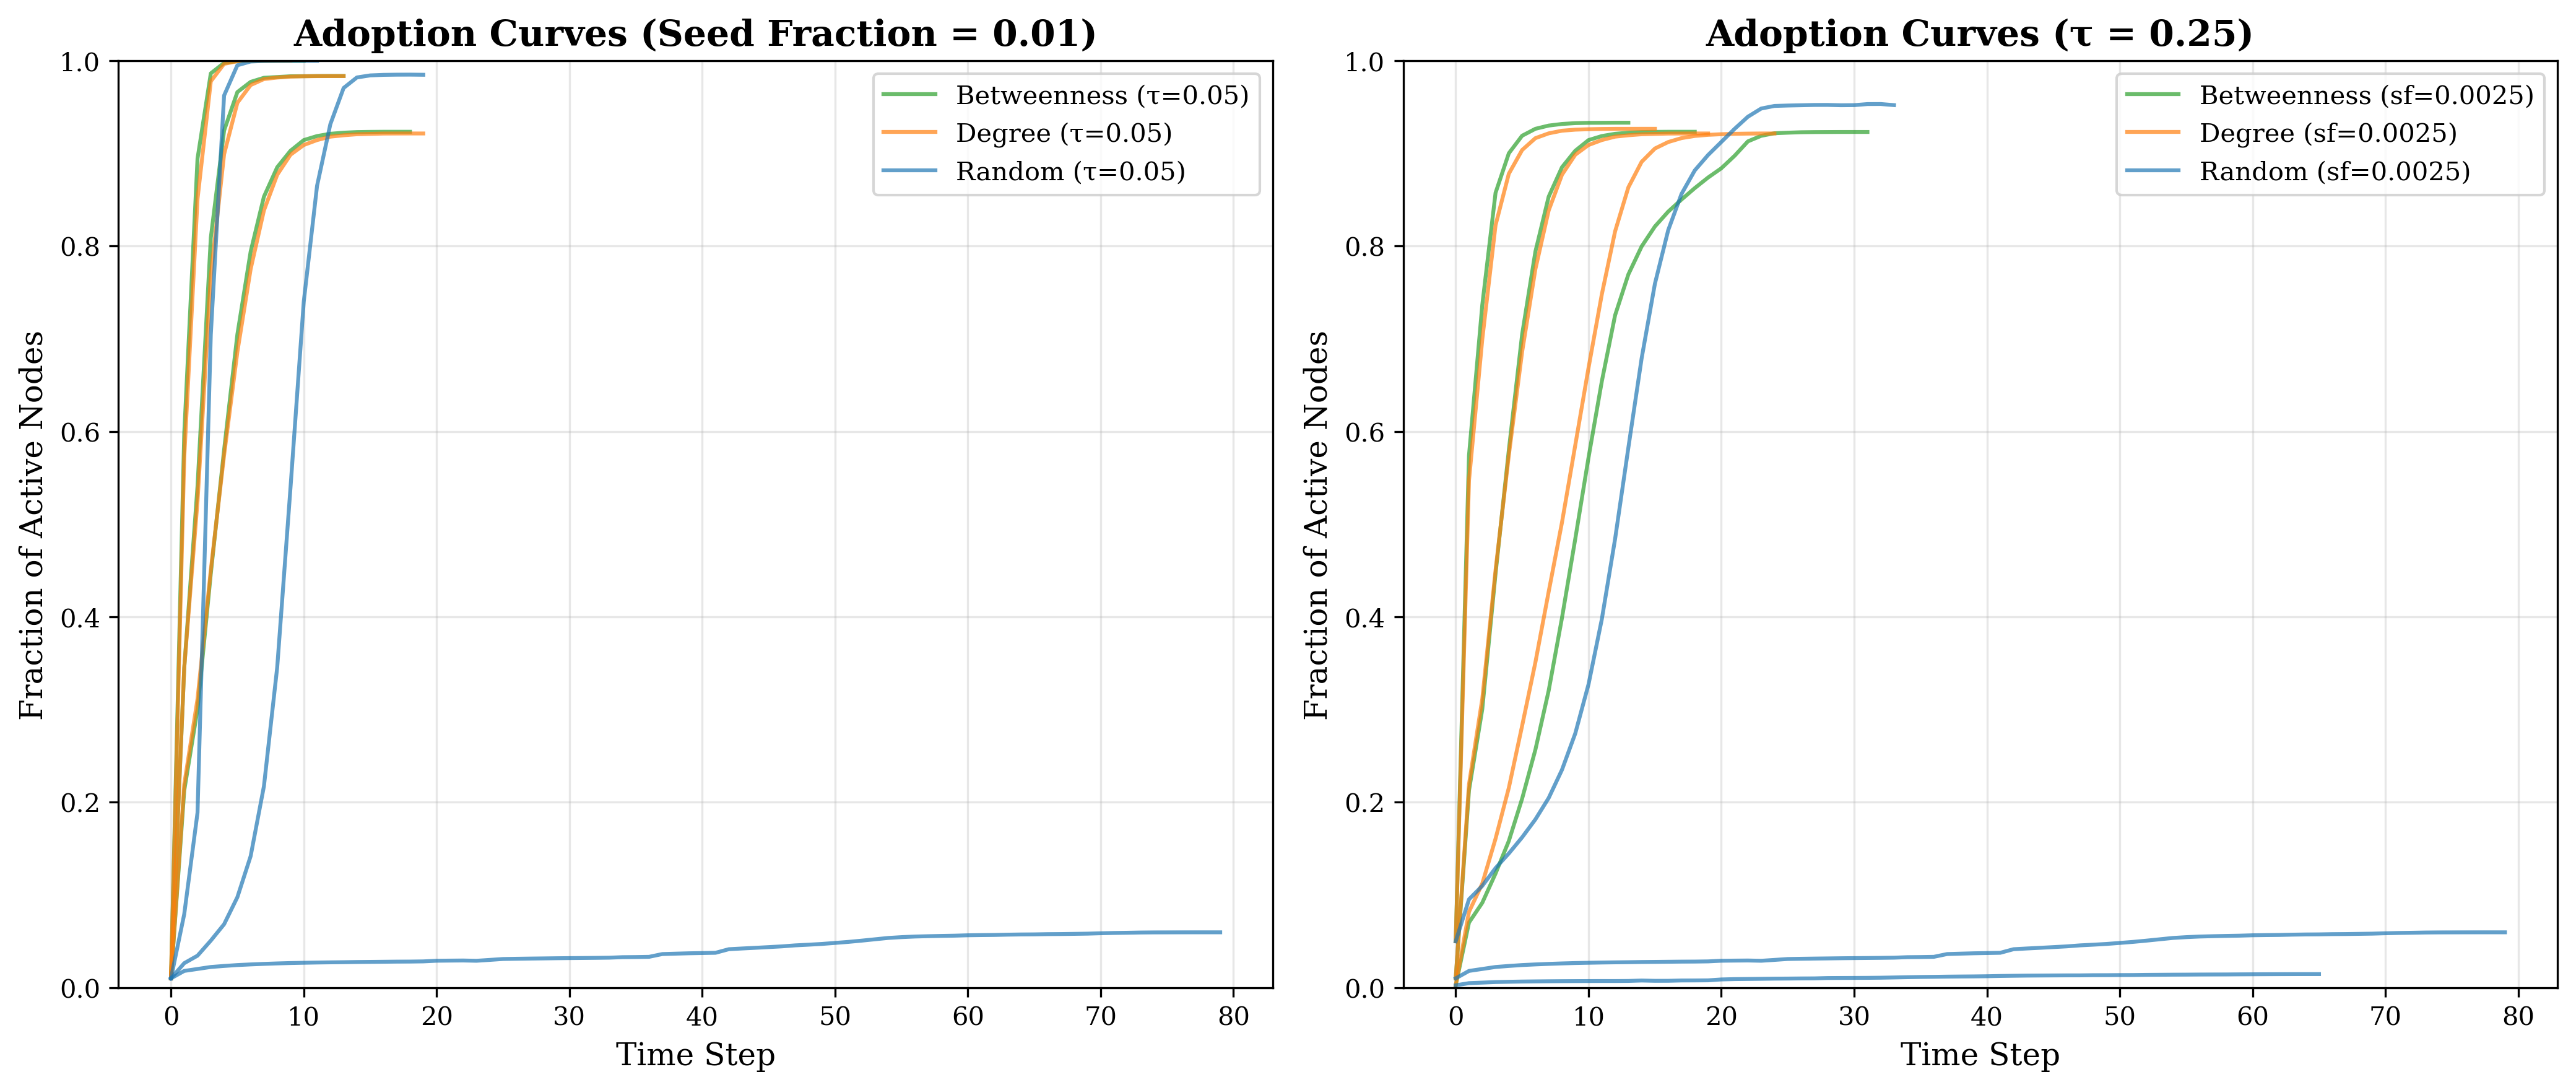

In [6]:
curves_df = data['mean_curves']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# varying tau, fixed seed fraction
seed_frac = curves_df['seed_fraction'].median()  
tau_subset = curves_df[curves_df['seed_fraction'] == seed_frac]

for strategy in tau_subset['strategy'].unique():
    strategy_data = tau_subset[tau_subset['strategy'] == strategy]
    color = STRATEGY_COLORS.get(strategy, 'gray')
    
    for tau in sorted(strategy_data['tau'].unique())[::2]:  
        tau_data = strategy_data[strategy_data['tau'] == tau]
        ax1.plot(tau_data['time_step'], tau_data['mean_fraction'], 
                color=color, alpha=0.7, linewidth=1.5,
                label=f'{STRATEGY_NAMES.get(strategy, strategy)} (τ={tau})' 
                if tau == sorted(strategy_data['tau'].unique())[0] else "")

ax1.set_xlabel('Time Step')
ax1.set_ylabel('Fraction of Active Nodes')
ax1.set_title(f'Adoption Curves (Seed Fraction = {seed_frac})', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# varying seed fraction, fixed tau
tau_val = curves_df['tau'].median()  
seed_subset = curves_df[curves_df['tau'] == tau_val]

for strategy in seed_subset['strategy'].unique():
    strategy_data = seed_subset[seed_subset['strategy'] == strategy]
    color = STRATEGY_COLORS.get(strategy, 'gray')
    
    for sf in sorted(strategy_data['seed_fraction'].unique())[::2]:  
        sf_data = strategy_data[strategy_data['seed_fraction'] == sf]
        ax2.plot(sf_data['time_step'], sf_data['mean_fraction'], 
                color=color, alpha=0.7, linewidth=1.5,
                label=f'{STRATEGY_NAMES.get(strategy, strategy)} (sf={sf})' 
                if sf == sorted(strategy_data['seed_fraction'].unique())[0] else "")

ax2.set_xlabel('Time Step')
ax2.set_ylabel('Fraction of Active Nodes')
ax2.set_title(f'Adoption Curves (τ = {tau_val})', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
# plt.savefig('adoption_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

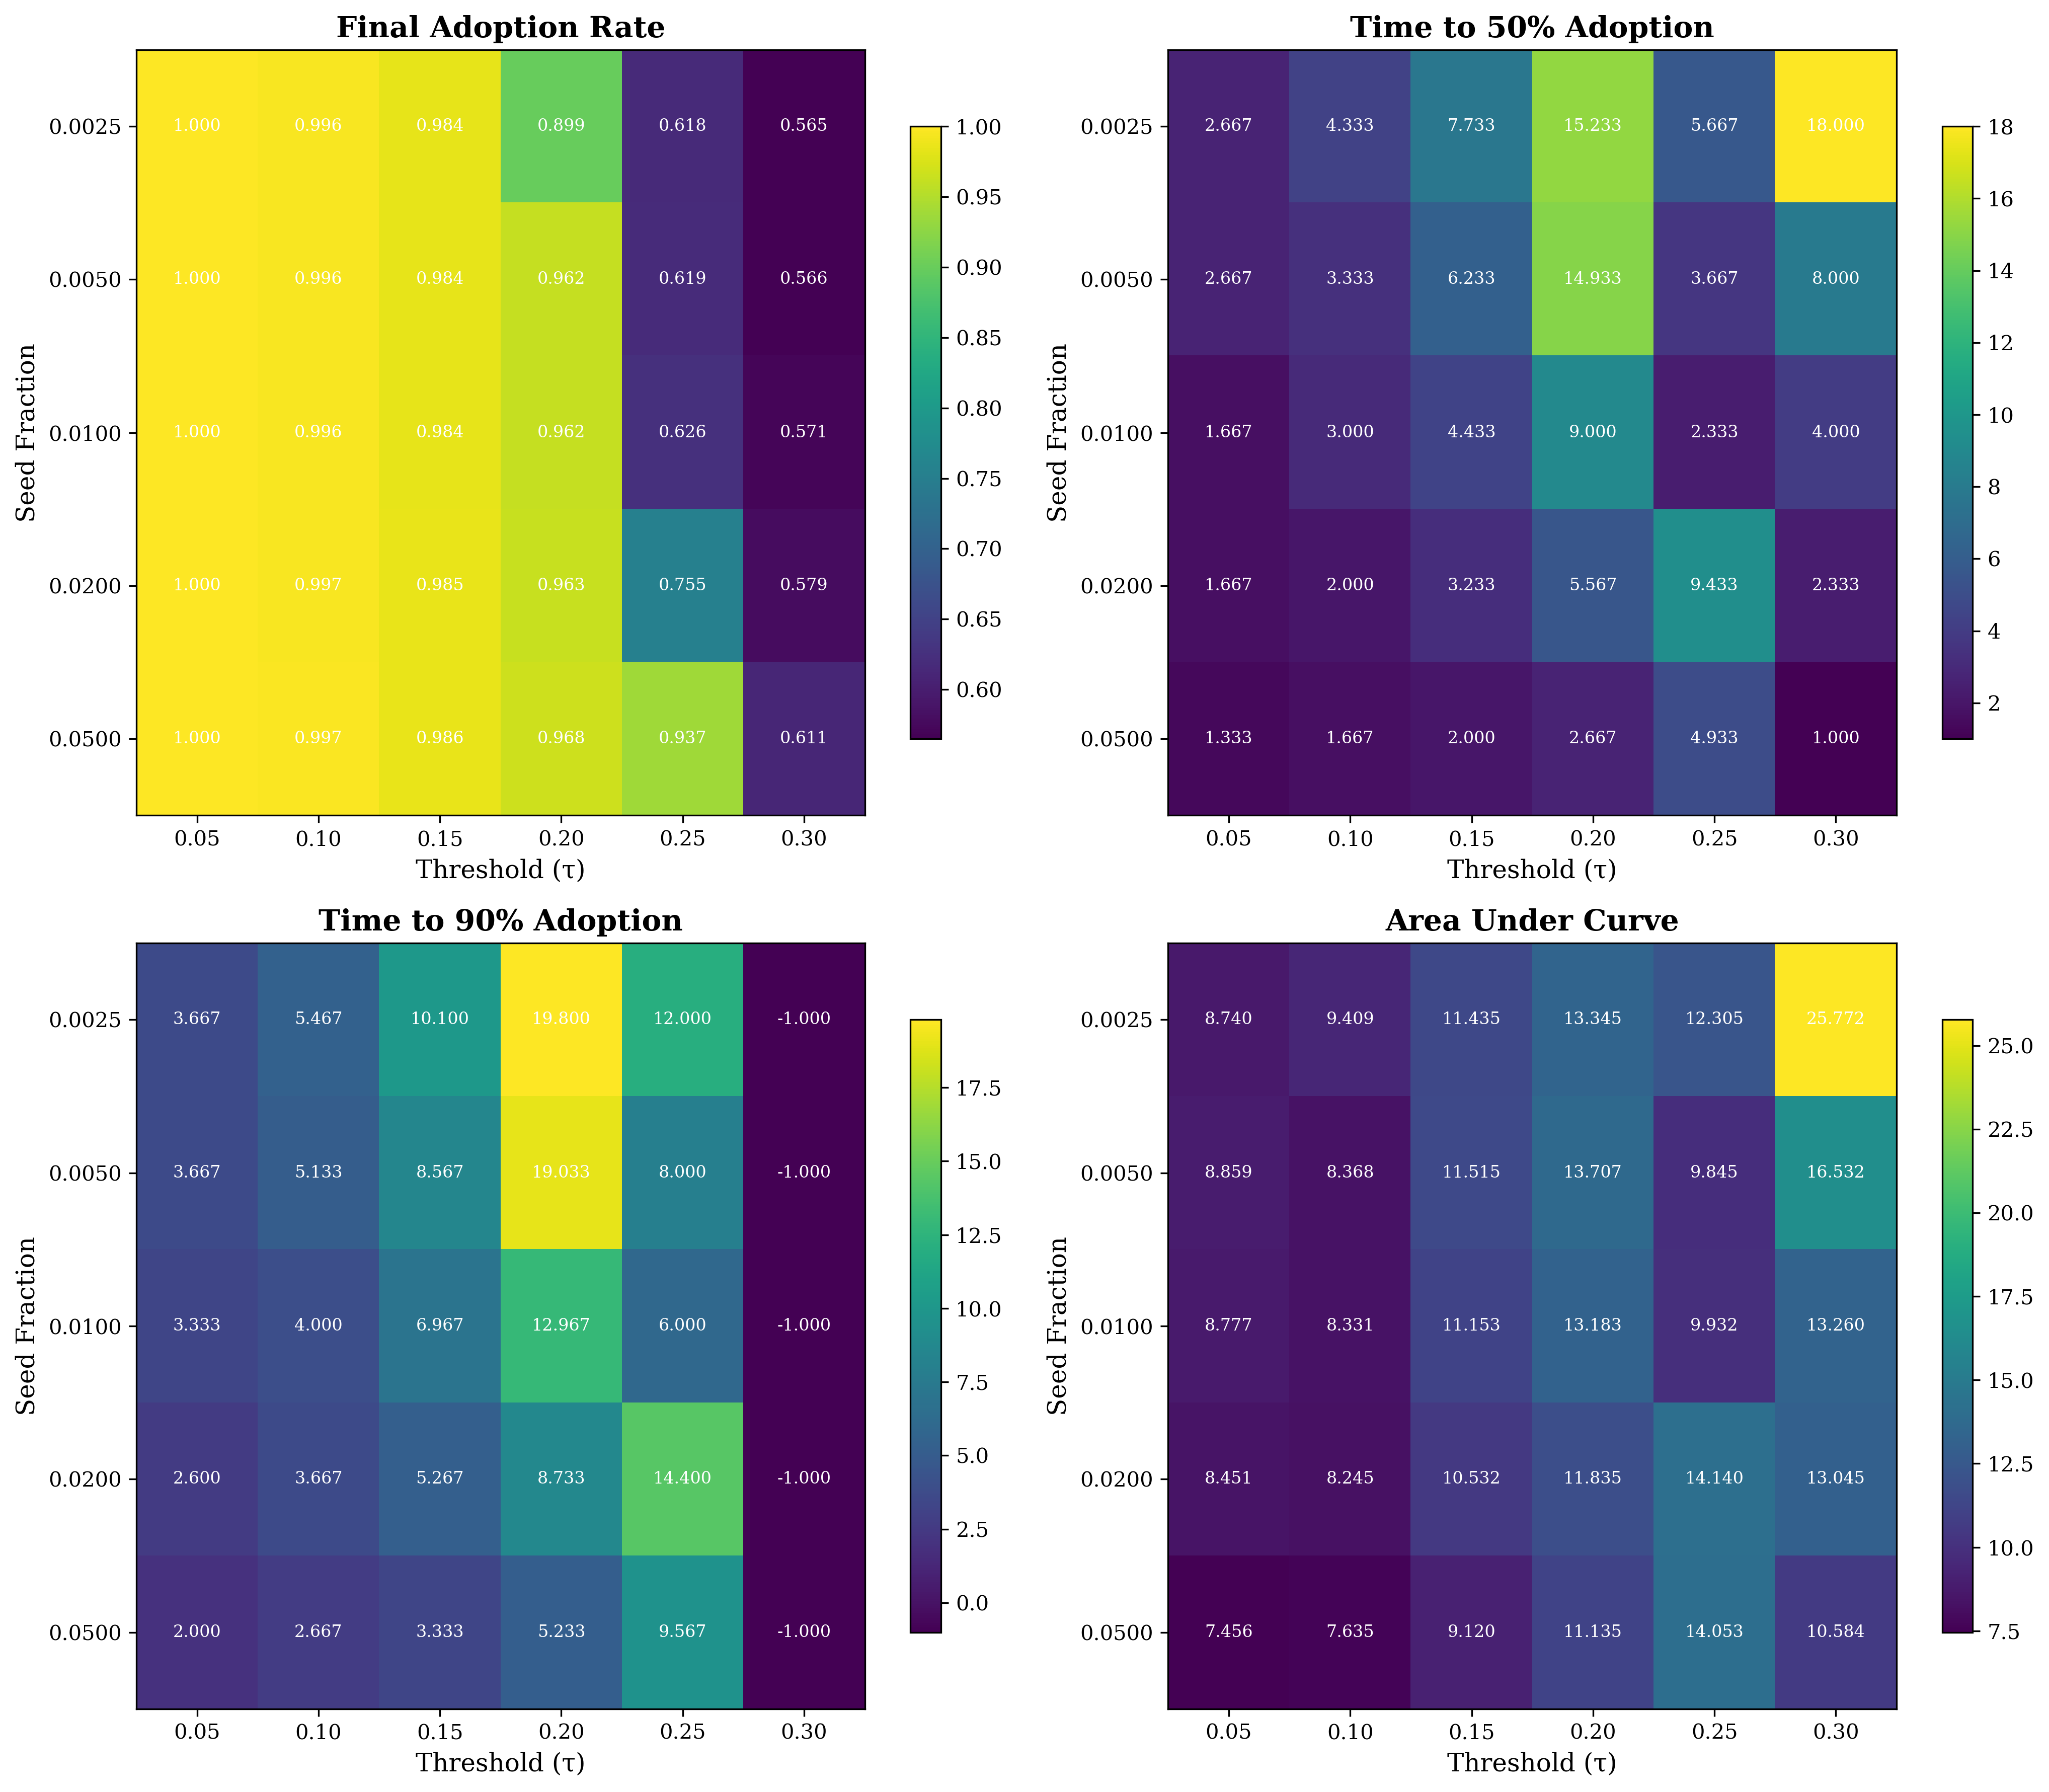

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
metrics = ['mean_final_fraction', 'mean_t_50', 'mean_t_90', 'mean_auc']
titles = ['Final Adoption Rate', 'Time to 50% Adoption', 'Time to 90% Adoption', 'Area Under Curve']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx//2, idx%2]
    
    pivot_data = agg_df.pivot_table(
        values=metric, 
        index='seed_fraction', 
        columns='tau', 
        aggfunc='mean'
    )
    
    im = ax.imshow(pivot_data.values, cmap='viridis', aspect='auto')
    
    ax.set_xticks(np.arange(len(pivot_data.columns)))
    ax.set_xticklabels([f'{x:.2f}' for x in pivot_data.columns])
    ax.set_yticks(np.arange(len(pivot_data.index)))
    ax.set_yticklabels([f'{x:.4f}' for x in pivot_data.index])
    
    ax.set_xlabel('Threshold (τ)')
    ax.set_ylabel('Seed Fraction')
    ax.set_title(title, fontweight='bold')

    # no grid
    ax.grid(False)
    
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            text = ax.text(j, i, f'{pivot_data.iloc[i, j]:.3f}',
                            ha="center", va="center", color="w", fontsize=8)

plt.tight_layout()
# plt.savefig('parameter_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\sabri\AppData\Local\Temp\ipykernel_12520\1193241202.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax1.boxplot(box_data, labels=[STRATEGY_NAMES.get(s, s) for s in strategies],


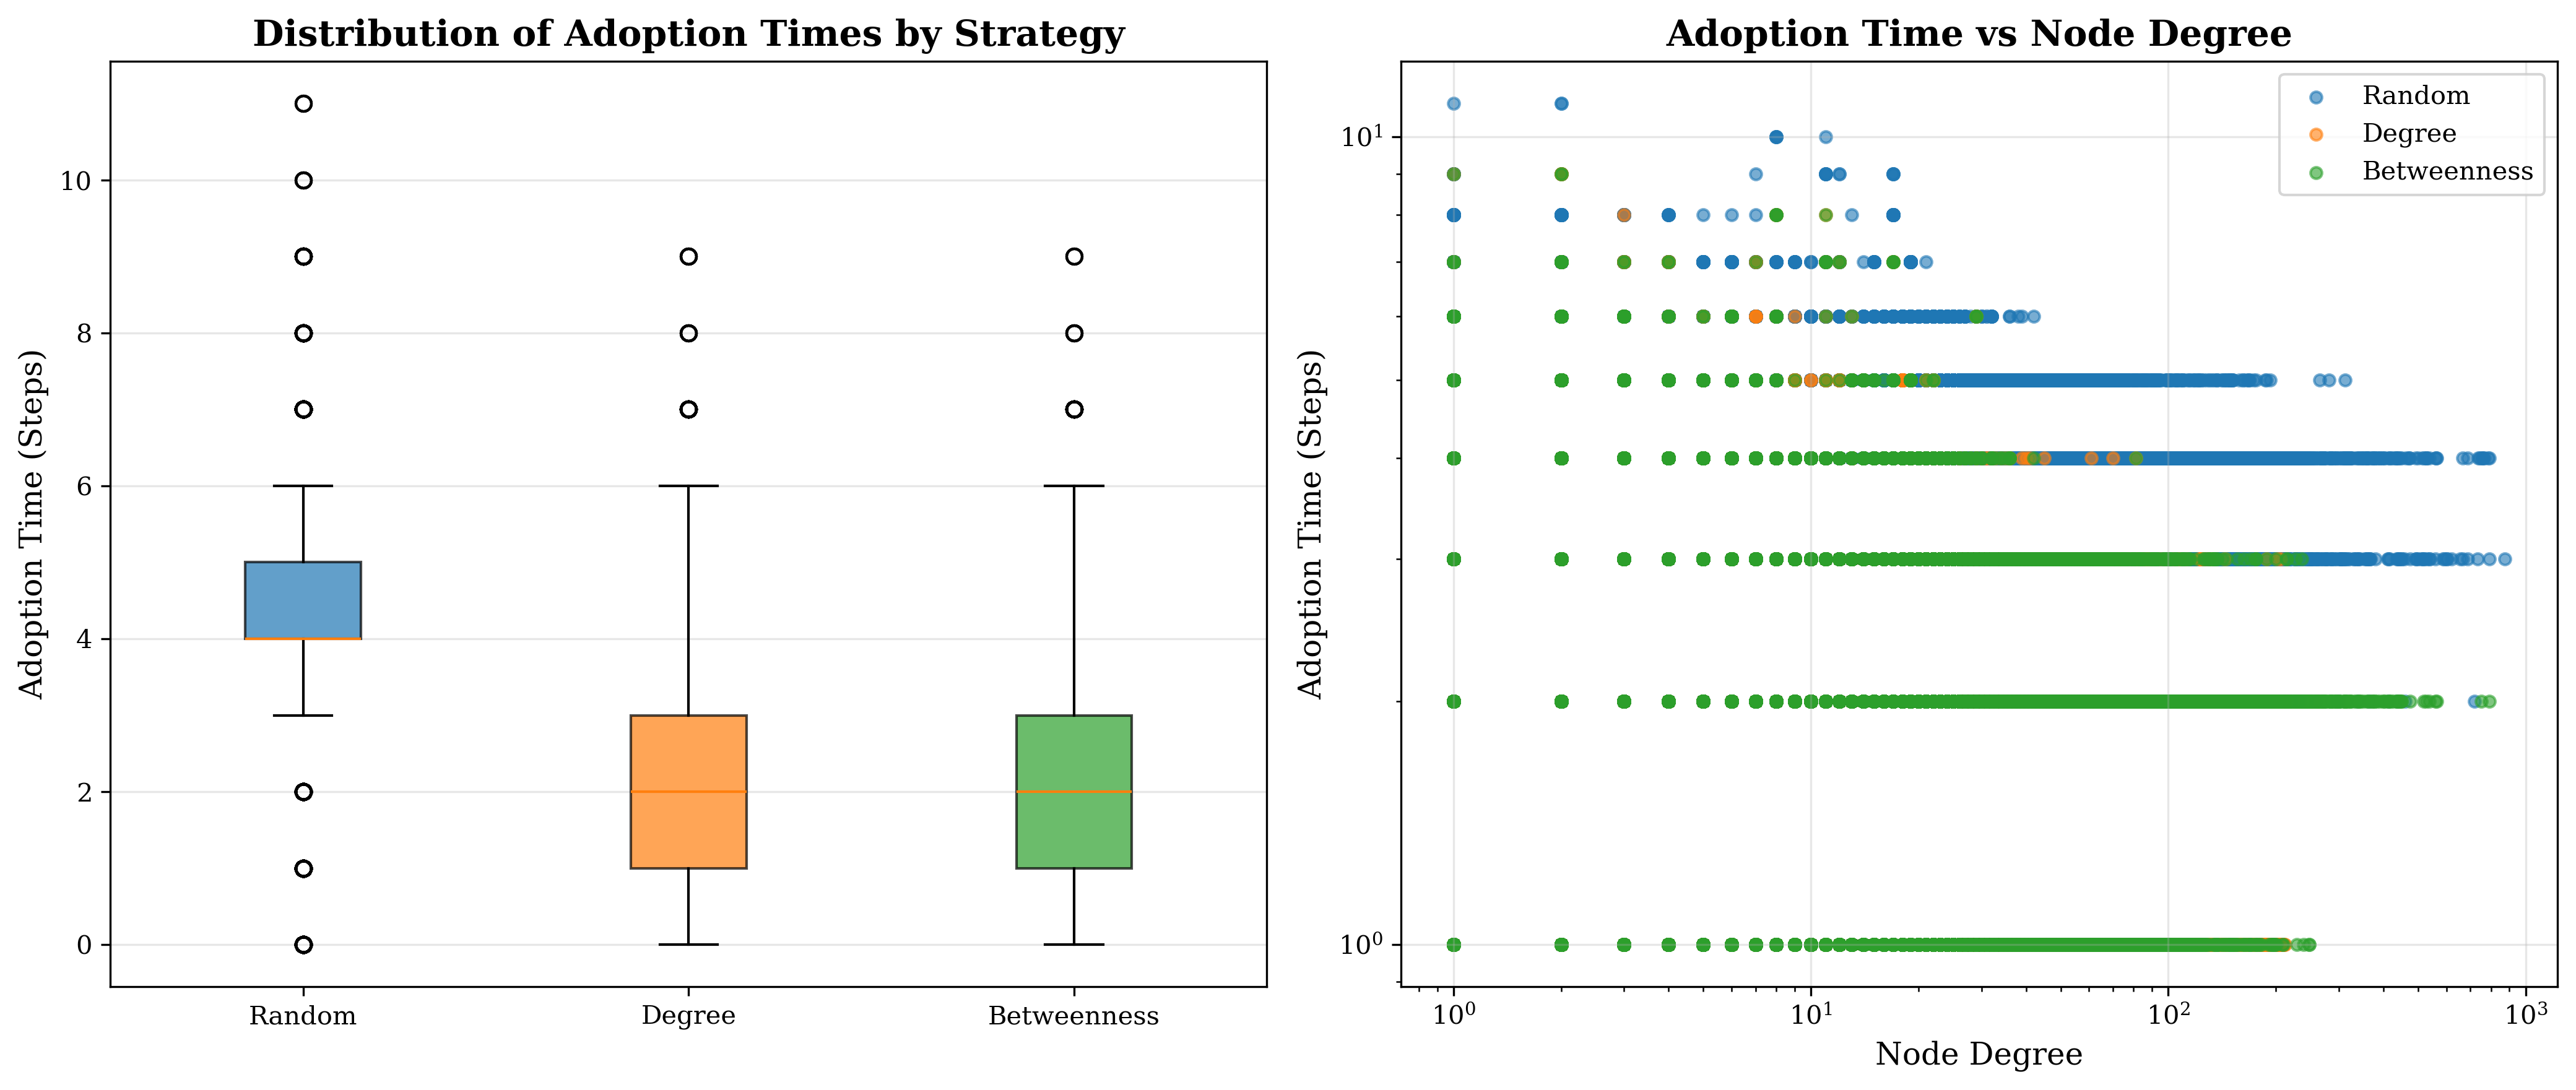

In [8]:
adopt_df = data['adoption_times']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# box plot of adoption times by strategy
adopt_df_filtered = adopt_df[adopt_df['adoption_time'] >= 0]  # Only adopted nodes

strategies = adopt_df_filtered['strategy'].unique()
box_data = [adopt_df_filtered[adopt_df_filtered['strategy'] == s]['adoption_time'] 
            for s in strategies]

box_plot = ax1.boxplot(box_data, labels=[STRATEGY_NAMES.get(s, s) for s in strategies],
                        patch_artist=True)

for patch, strategy in zip(box_plot['boxes'], strategies):
    patch.set_facecolor(STRATEGY_COLORS.get(strategy, 'gray'))
    patch.set_alpha(0.7)

ax1.set_ylabel('Adoption Time (Steps)')
ax1.set_title('Distribution of Adoption Times by Strategy', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# scatter plot of adoption time vs degree
for strategy in strategies:
    strategy_data = adopt_df_filtered[adopt_df_filtered['strategy'] == strategy]
    color = STRATEGY_COLORS.get(strategy, 'gray')
    ax2.scatter(strategy_data['degree'], strategy_data['adoption_time'], 
                alpha=0.6, s=20, color=color, 
                label=STRATEGY_NAMES.get(strategy, strategy))

ax2.set_xlabel('Node Degree')
ax2.set_ylabel('Adoption Time (Steps)')
ax2.set_title('Adoption Time vs Node Degree', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')
ax2.set_xscale('log')

plt.tight_layout()
# plt.savefig('adoption_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

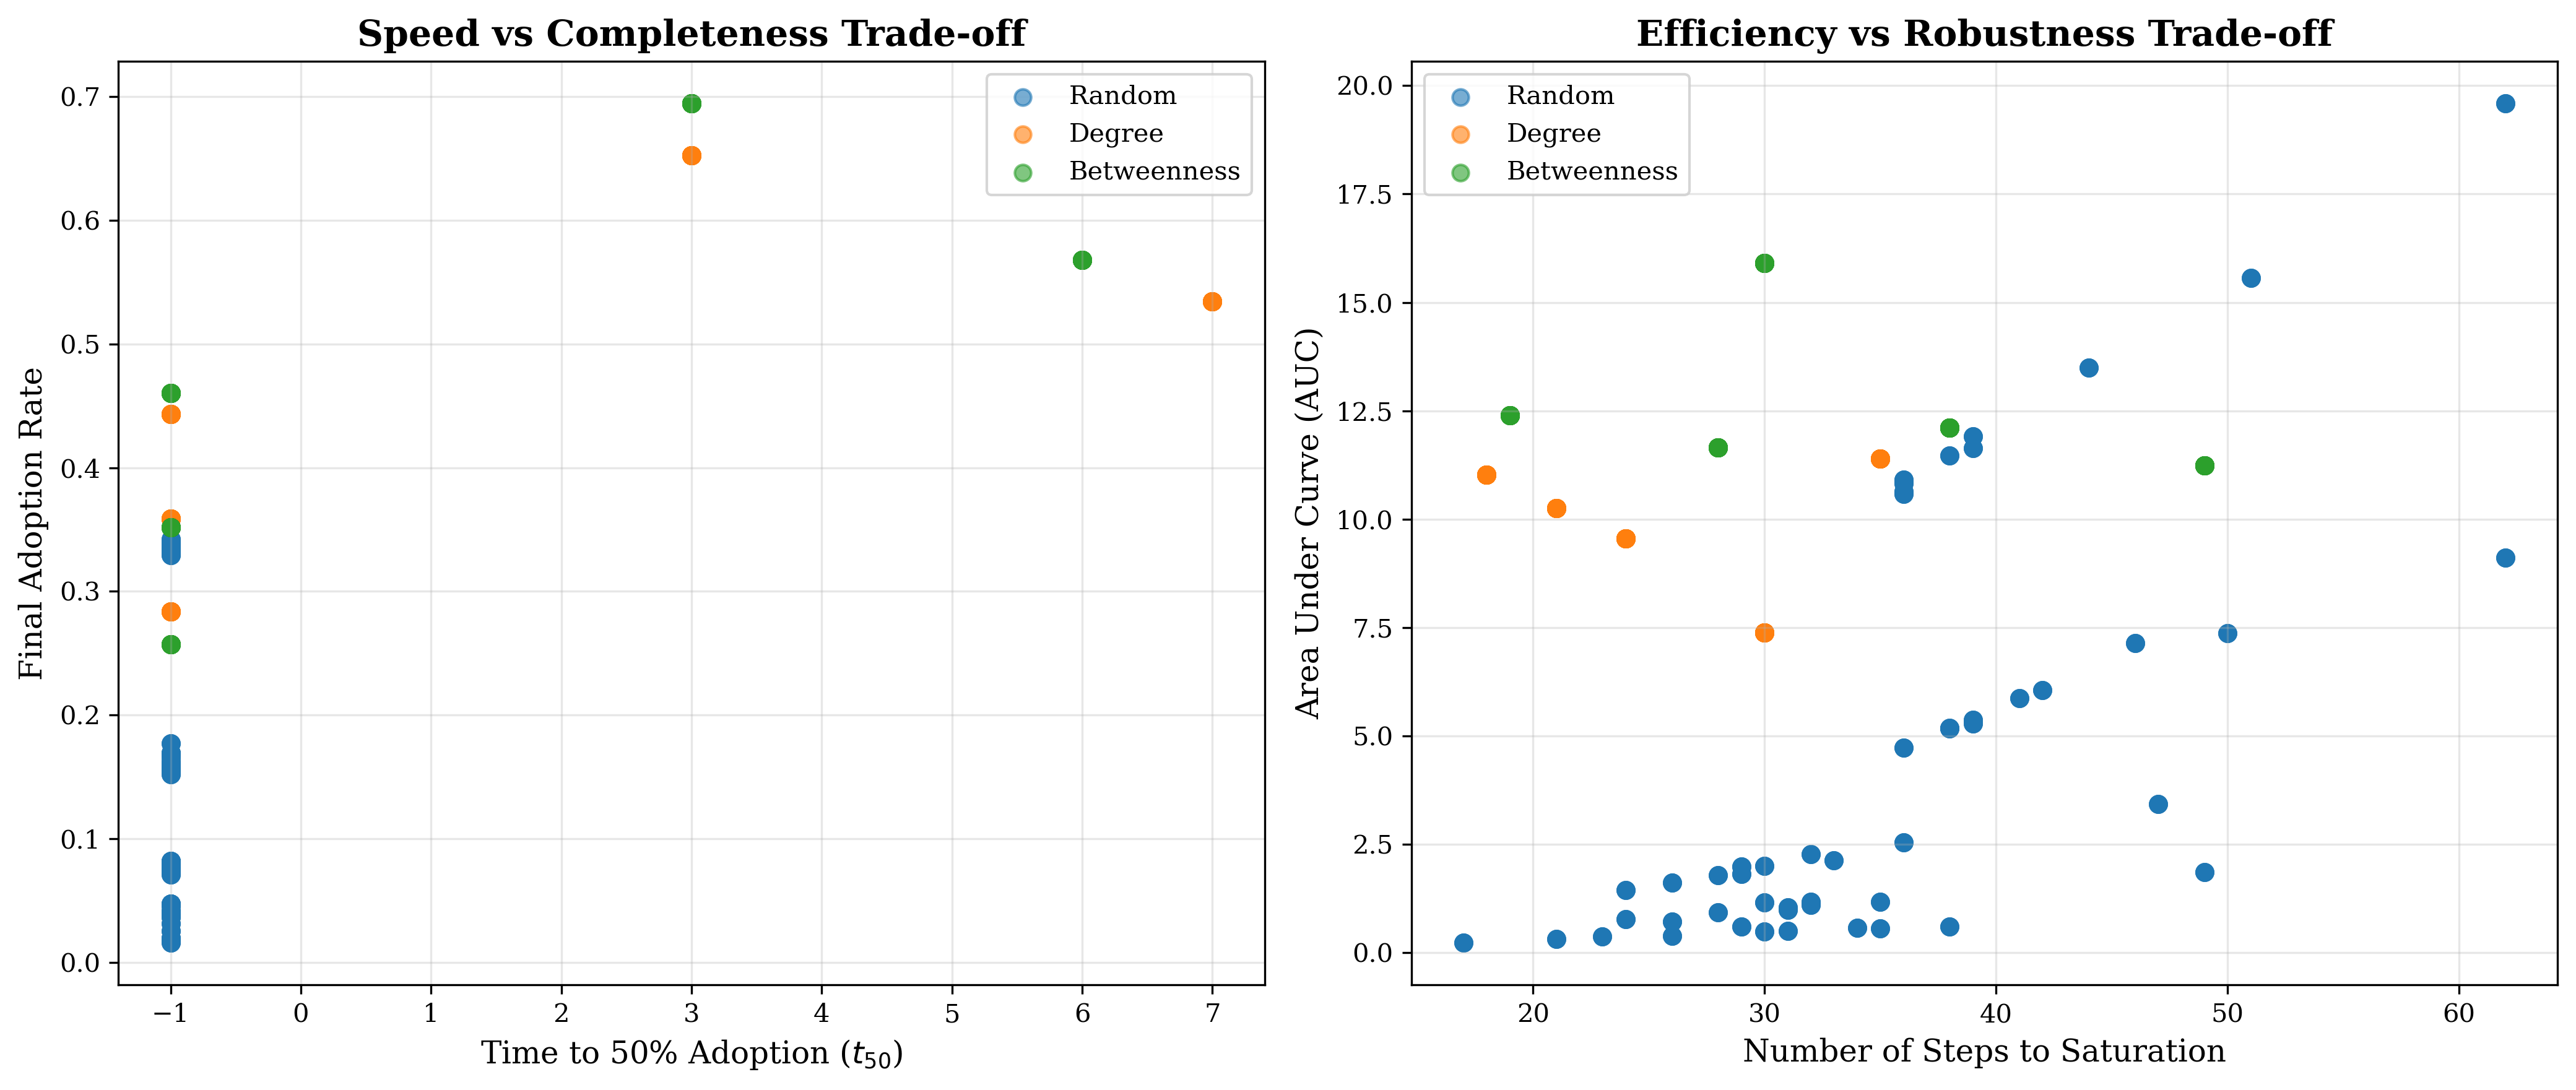

In [11]:
per_run_df = data['per_run']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# speed vs completeness tradeoff
for strategy in per_run_df['strategy'].unique():
    strategy_data = per_run_df[per_run_df['strategy'] == strategy]
    color = STRATEGY_COLORS.get(strategy, 'gray')
    
    ax1.scatter(strategy_data['t_50'], strategy_data['final_fraction'],
                alpha=0.6, s=40, color=color,
                label=STRATEGY_NAMES.get(strategy, strategy))

ax1.set_xlabel('Time to 50% Adoption ($t_{50}$)')
ax1.set_ylabel('Final Adoption Rate')
ax1.set_title('Speed vs Completeness Trade-off', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# efficiency vs robustness tradeoff
for strategy in per_run_df['strategy'].unique():
    strategy_data = per_run_df[per_run_df['strategy'] == strategy]
    color = STRATEGY_COLORS.get(strategy, 'gray')
    
    ax2.scatter(strategy_data['n_steps'], strategy_data['auc'],
                alpha=0.6, s=40, color=color,
                label=STRATEGY_NAMES.get(strategy, strategy))

ax2.set_xlabel('Number of Steps to Saturation')
ax2.set_ylabel('Area Under Curve (AUC)')
ax2.set_title('Efficiency vs Robustness Trade-off', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('performance_tradeoffs.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

# Group by strategy and compute overall means
summary = agg_df.groupby('strategy').agg({
    'mean_final_fraction': 'mean',
    'mean_t_50': 'mean', 
    'mean_t_90': 'mean',
    'mean_auc': 'mean',
    'mean_n_steps': 'mean'
}).round(4)

print(summary)
print("\n")

# Best performing strategy for each metric
metrics = {
    'mean_final_fraction': 'Final Adoption Rate (higher better)',
    'mean_t_50': 'Time to 50% Adoption (lower better)',
    'mean_t_90': 'Time to 90% Adoption (lower better)', 
    'mean_auc': 'Area Under Curve (higher better)',
    'mean_n_steps': 'Steps to Saturation (lower better)'
}

print("BEST PERFORMING STRATEGIES:")
print("-" * 40)

for metric, description in metrics.items():
    if 't_50' in metric or 't_90' in metric or 'n_steps' in metric:
        best_strategy = summary[metric].idxmin()
        best_value = summary[metric].min()
        comparison = "lower"
    else:
        best_strategy = summary[metric].idxmax() 
        best_value = summary[metric].max()
        comparison = "higher"
        
    print(f"{description:35} | {STRATEGY_NAMES.get(best_strategy, best_strategy):12} ({best_value:.4f}, {comparison})")


SUMMARY STATISTICS
             mean_final_fraction  mean_t_50  mean_t_90  mean_auc  mean_n_steps
strategy                                                                      
betweenness               0.4664        1.2       -1.0   12.6613         32.80
degree                    0.4546        1.4       -1.0    9.9244         25.60
random                    0.1270       -1.0       -1.0    4.4923         35.28


BEST PERFORMING STRATEGIES:
----------------------------------------
Final Adoption Rate (higher better) | Betweenness  (0.4664, higher)
Time to 50% Adoption (lower better) | Random       (-1.0000, lower)
Time to 90% Adoption (lower better) | Betweenness  (-1.0000, lower)
Area Under Curve (higher better)    | Betweenness  (12.6613, higher)
Steps to Saturation (lower better)  | Degree       (25.6000, lower)


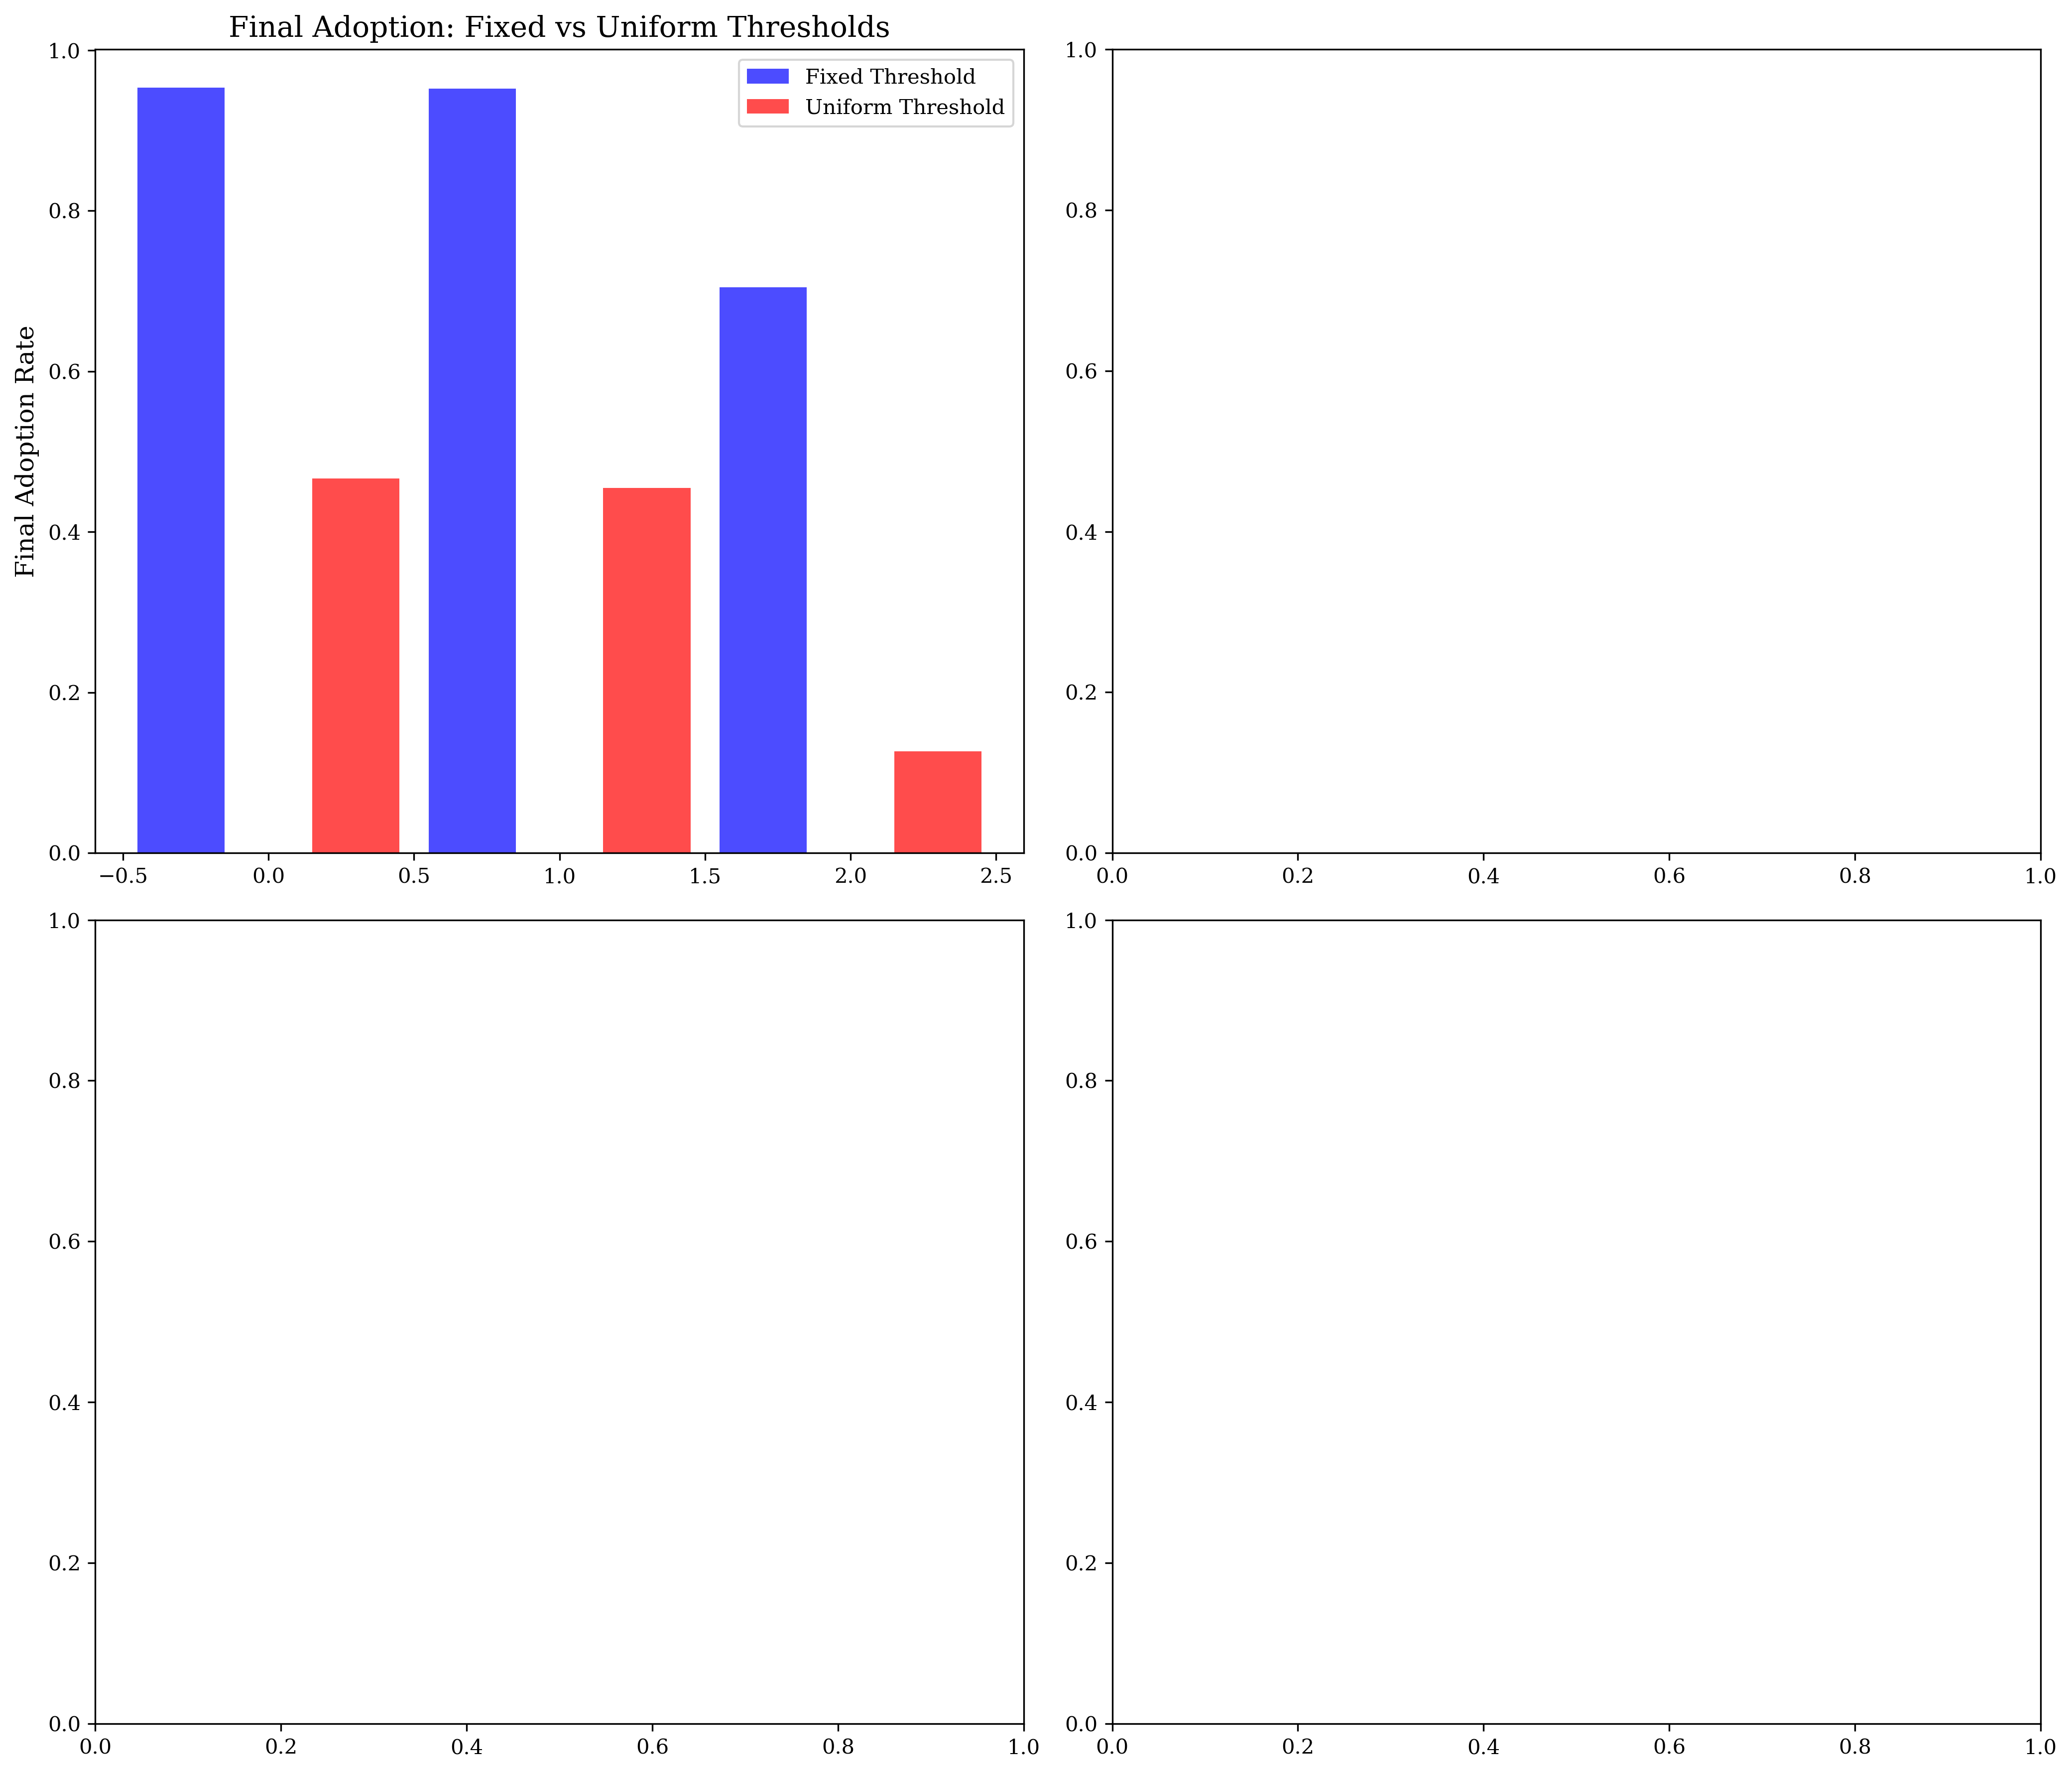

In [4]:

# Load both datasets
fixed_data = {
    'per_run': pd.read_csv('ass2_per_run_all.csv'),
    'aggregate': pd.read_csv('ass2_aggregate_all.csv'),
    'mean_curves': pd.read_csv('ass2_mean_curves_all.csv')
}

uniform_data = {
    'per_run': pd.read_csv('ass2_uniform_per_run_all.csv'), 
    'aggregate': pd.read_csv('ass2_uniform_aggregate_all.csv'),
    'mean_curves': pd.read_csv('ass2_uniform_mean_curves_all.csv')
}

# Create comparison plots
def plot_threshold_mode_comparison(fixed_data, uniform_data):
    """Compare fixed vs uniform threshold modes"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Final adoption comparison
    for mode, data, color, label in [
        ('fixed', fixed_data['aggregate'], 'blue', 'Fixed Threshold'),
        ('uniform', uniform_data['aggregate'], 'red', 'Uniform Threshold')
    ]:
        strategies = data['strategy'].unique()
        x_pos = np.arange(len(strategies))
        
        for i, strategy in enumerate(strategies):
            strategy_data = data[data['strategy'] == strategy]
            axes[0,0].bar(x_pos[i] + (0.3 if mode == 'uniform' else -0.3), 
                         strategy_data['mean_final_fraction'].mean(),
                         width=0.3, color=color, alpha=0.7,
                         label=label if i == 0 else "")
    
    axes[0,0].set_title('Final Adoption: Fixed vs Uniform Thresholds')
    axes[0,0].set_ylabel('Final Adoption Rate')
    axes[0,0].legend()
    
    # Add more comparison plots as needed...
    
    plt.tight_layout()
    plt.savefig('threshold_mode_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_threshold_mode_comparison(fixed_data, uniform_data)